In [2]:
import pandas as pd

df = pd.read_csv("./normalized_landmark_data_with_motion.csv")
X = df.drop(columns=["Video_Filename", "frame", "label"])  # 136D normalized features
y = df["label"]

X.head()
print(X.columns.tolist())

['norm_pt_0', 'norm_pt_1', 'norm_pt_2', 'norm_pt_3', 'norm_pt_4', 'norm_pt_5', 'norm_pt_6', 'norm_pt_7', 'norm_pt_8', 'norm_pt_9', 'norm_pt_10', 'norm_pt_11', 'norm_pt_12', 'norm_pt_13', 'norm_pt_14', 'norm_pt_15', 'norm_pt_16', 'norm_pt_17', 'norm_pt_18', 'norm_pt_19', 'norm_pt_20', 'norm_pt_21', 'norm_pt_22', 'norm_pt_23', 'norm_pt_24', 'norm_pt_25', 'norm_pt_26', 'norm_pt_27', 'norm_pt_28', 'norm_pt_29', 'norm_pt_30', 'norm_pt_31', 'norm_pt_32', 'norm_pt_33', 'norm_pt_34', 'norm_pt_35', 'norm_pt_36', 'norm_pt_37', 'norm_pt_38', 'norm_pt_39', 'norm_pt_40', 'norm_pt_41', 'norm_pt_42', 'norm_pt_43', 'norm_pt_44', 'norm_pt_45', 'norm_pt_46', 'norm_pt_47', 'norm_pt_48', 'norm_pt_49', 'norm_pt_50', 'norm_pt_51', 'norm_pt_52', 'norm_pt_53', 'norm_pt_54', 'norm_pt_55', 'norm_pt_56', 'norm_pt_57', 'norm_pt_58', 'norm_pt_59', 'norm_pt_60', 'norm_pt_61', 'norm_pt_62', 'norm_pt_63', 'norm_pt_64', 'norm_pt_65', 'norm_pt_66', 'norm_pt_67', 'norm_pt_68', 'norm_pt_69', 'norm_pt_70', 'norm_pt_71', '

In [3]:
#!pip install scikit-learn
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

print("Accuracy:", clf.score(X_test, y_test))

y_pred = clf.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))



Accuracy: 0.8131868131868132
[[ 55  36]
 [ 15 167]]
              precision    recall  f1-score   support

           0       0.79      0.60      0.68        91
           1       0.82      0.92      0.87       182

    accuracy                           0.81       273
   macro avg       0.80      0.76      0.78       273
weighted avg       0.81      0.81      0.81       273



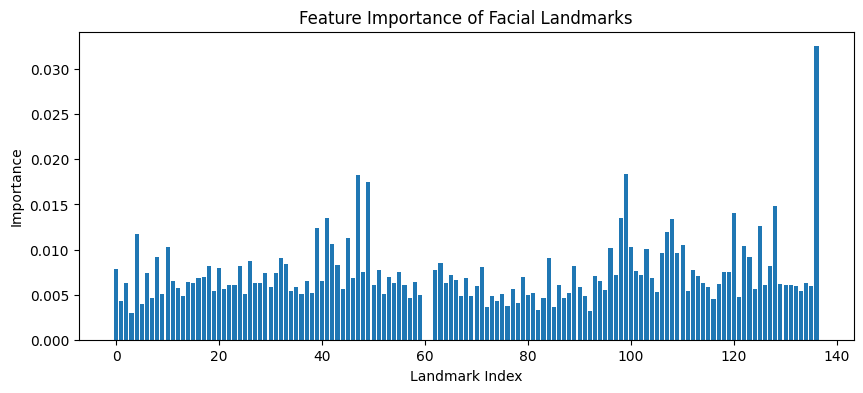

In [4]:
import matplotlib.pyplot as plt

importances = clf.feature_importances_
plt.figure(figsize=(10, 4))
plt.bar(range(len(importances)), importances)
plt.title("Feature Importance of Facial Landmarks")
plt.xlabel("Landmark Index")
plt.ylabel("Importance")
plt.show()


In [5]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

X = df.drop(columns=["Video_Filename", "frame", "label"])
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[ 55  36]
 [  8 174]]
              precision    recall  f1-score   support

           0       0.87      0.60      0.71        91
           1       0.83      0.96      0.89       182

    accuracy                           0.84       273
   macro avg       0.85      0.78      0.80       273
weighted avg       0.84      0.84      0.83       273



In [6]:
import joblib

joblib.dump(clf, "rf_face_model.pkl")
model.save_model("xgb_face_model.json")

Features from X: 137
Feature importances from model: 137
[0.007875744183287894, 0.004300378327590537, 0.006291700138942472, 0.002945523251717862, 0.01173356960207106, 0.003907691194536957, 0.007427080723457774, 0.004678535538563147, 0.009192354173097906, 0.005053936633435068, 0.010333508609240595, 0.006513403847769748, 0.005749230860456501, 0.004900702441896089, 0.006441759723945289, 0.0062966867642660265, 0.006855714102759838, 0.006913958682875147, 0.008226919992201341, 0.0053952228817441186, 0.007966451075759594, 0.00559743810614621, 0.006103040103171982, 0.006087649960937775, 0.008160768002194065, 0.005063071666620138, 0.008737207058707178, 0.00633986667793684, 0.006238196548105297, 0.0074031819737514215, 0.0058978749413248965, 0.007451187477181391, 0.00906196988828133, 0.008447826054115749, 0.005417949392010028, 0.005850712517083283, 0.005017924849964519, 0.006495646623834795, 0.005215779953643803, 0.012436220023330885, 0.0064817318313524115, 0.013495613037452378, 0.010634277909737

C:\Users\connellj2\AppData\Local\Temp\ipykernel_23672\1581235914.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_20.values, y=top_20.index, palette="viridis")


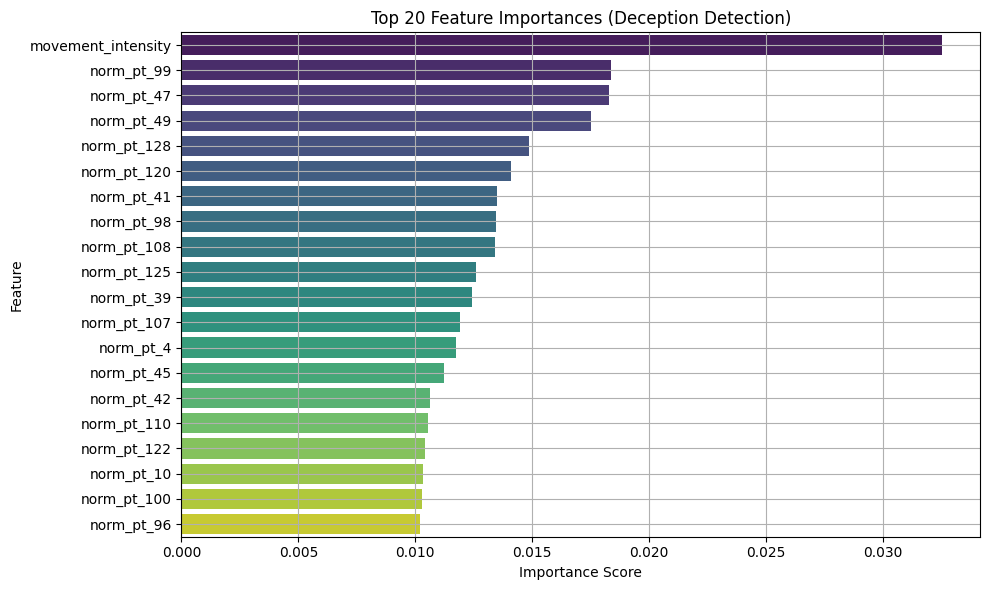

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Features from X:", len(X.columns))
print("Feature importances from model:", len(clf.feature_importances_))

print(clf.feature_importances_.tolist())


# Extract top 20 features
feat_importance = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
top_20 = feat_importance.head(20)

# Plot them
plt.figure(figsize=(10,6))
sns.barplot(x=top_20.values, y=top_20.index, palette="viridis")
plt.title("Top 20 Feature Importances (Deception Detection)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.grid(True)
plt.show()


In [68]:
feat_importance = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
motion_rank = feat_importance.index.get_loc("movement_intensity") + 1  # zero-based index → 1-based rank
print(f"📦 'movement_intensity' ranks #{motion_rank} in feature importance.")


📦 'movement_intensity' ranks #1 in feature importance.
